# **CNN Development on Intel Image Classification Dataset**

---


This notebook presents a complete PyTorch-based Convolutional Neural Network (CNN) pipeline for multi-class image classification using the Intel Image Classification dataset. The task includes dataset loading, preprocessing, CNN design, model training, evaluation, visualization, regularization comparison, and saving trained model weights.

**Mount Google Drive and Extract Dataset**

---

The Intel Image Classification dataset was stored in Google Drive as a zip file. In this section, Google Drive is mounted and the dataset is extracted into the Colab working directory.

In [59]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -o "/content/drive/MyDrive/CVPR/Intel.zip" -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/seg_train/seg_train/mountain/7506.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7537.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7539.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7551.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7560.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7565.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7578.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7581.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7586.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7647.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7652.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7654.jpg  
  inflating: /content/dataset/seg_train/seg_train/mountain/7662.jpg  
  inflating: /content/dataset/seg_train

In [32]:
!pip install torchinfo -q

**1. Import Libraries**

---


In this section, I imported the required libraries for data loading, preprocessing, model building, training, evaluation, and visualization.

In [60]:
import os
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    accuracy_score
)
from torchinfo import summary

In [61]:
!find /content/dataset -maxdepth 3 -type d

/content/dataset
/content/dataset/seg_test
/content/dataset/seg_test/seg_test
/content/dataset/seg_test/seg_test/street
/content/dataset/seg_test/seg_test/glacier
/content/dataset/seg_test/seg_test/mountain
/content/dataset/seg_test/seg_test/forest
/content/dataset/seg_test/seg_test/sea
/content/dataset/seg_test/seg_test/buildings
/content/dataset/seg_pred
/content/dataset/seg_pred/seg_pred
/content/dataset/seg_train
/content/dataset/seg_train/seg_train
/content/dataset/seg_train/seg_train/street
/content/dataset/seg_train/seg_train/glacier
/content/dataset/seg_train/seg_train/mountain
/content/dataset/seg_train/seg_train/forest
/content/dataset/seg_train/seg_train/sea
/content/dataset/seg_train/seg_train/buildings


**3. Configuration and Hyperparameters**

---

This section defines the main configuration settings used in the experiment, such as dataset paths, batch size, number of epochs, learning rate, weight decay, random seed, and model save paths.

In [62]:

train_dir = "/content/dataset/seg_train/seg_train"
test_dir = "/content/dataset/seg_test/seg_test"

STUDENT_ID = "22_49008_3"
BATCH_SIZE = 32
NUM_EPOCHS = 8
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
RANDOM_SEED = 42

MODEL_SIMPLE_PATH = f"intel_cnn_simple_{STUDENT_ID}.pth"
MODEL_REG_PATH = f"intel_cnn_regularized_{STUDENT_ID}.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

Using device: cuda


**Data Preprocessing and Augmentation**

---
Training images were resized and augmented using random horizontal flipping and random rotation. Validation and test images were resized and normalized without augmentation to ensure fair evaluation.


In [63]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

**Hyperparameter Details and Rationale**

---

The following hyperparameters were used in this experiment:

- Image size: 128 × 128  
  This size preserves important scene details while keeping training computationally manageable.

- Batch size: 32  
  This batch size provides stable gradient updates and works well with available GPU memory.

- Number of epochs: 8  
  A moderate number of epochs was selected to balance performance and training time.

- Learning rate: 0.001  
  This is a common starting point for Adam and supports stable learning.

- Weight decay: 1e-4  
  This helps reduce overfitting and improves generalization.

- Optimizer: Adam  
  Adam was selected because it converges efficiently for image classification tasks.

- Loss function: CrossEntropyLoss  
  This is suitable for multi-class classification problems.

- Scheduler: StepLR  
  The learning rate scheduler gradually reduces the learning rate during training to improve convergence.

- Batch Normalization and Dropout  
  These were used in the regularized model to stabilize training and reduce overfitting.


In [64]:

full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
full_val_dataset = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_indices, val_indices = random_split(
    range(len(full_train_dataset)),
    [train_size, val_size],
    generator=generator
)

train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices.indices)
val_dataset = torch.utils.data.Subset(full_val_dataset, val_indices.indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6
Train samples: 11227
Validation samples: 2807
Test samples: 3000


**Load and Explore Dataset**

---
The dataset was loaded using PyTorch ImageFolder. Separate datasets were prepared for training, validation, and testing. Sample images were displayed to verify correct loading and class labels.


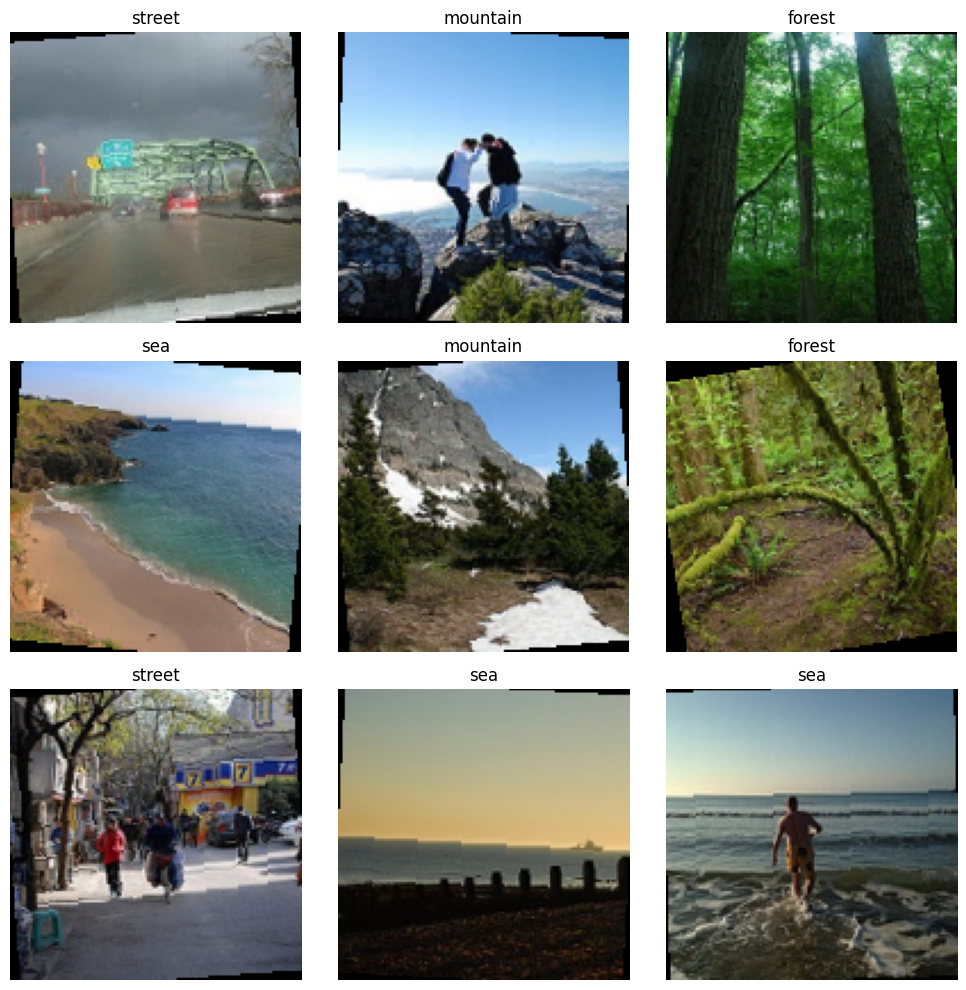

In [65]:

def show_images(loader, class_names):
    images, labels = next(iter(loader))
    images = images[:9]
    labels = labels[:9]

    plt.figure(figsize=(10, 10))
    for i in range(len(images)):
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_images(train_loader, class_names)

**Define CNN Architecture**

---
A custom CNN architecture was designed for this task. Two versions were used: a simple CNN without regularization and a regularized CNN with batch normalization and dropout. This helps compare the effect of regularization on performance.


In [66]:

class CustomCNN(nn.Module):
    def __init__(self, num_classes, use_bn=False, use_dropout=False, dropout_rate=0.5):
        super(CustomCNN, self).__init__()

        self.use_bn = use_bn
        self.use_dropout = use_dropout

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        if self.use_bn:
            x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        if self.use_bn:
            x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)

        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc2(x)
        return x

**Model Summary**

---

The architecture summaries of both CNN models are shown below. These summaries help verify the input-output dimensions, total number of parameters, and structural differences between the simple and regularized models.

In [67]:

model_simple = CustomCNN(num_classes=num_classes, use_bn=False, use_dropout=False).to(device)
print("Simple CNN Summary:")
summary(model_simple, input_size=(32, 3, 128, 128))

model_regularized = CustomCNN(num_classes=num_classes, use_bn=True, use_dropout=True).to(device)
print("\nRegularized CNN Summary:")
summary(model_regularized, input_size=(32, 3, 128, 128))

Simple CNN Summary:

Regularized CNN Summary:


Layer (type:depth-idx)                   Output Shape              Param #
CustomCNN                                [32, 6]                   --
├─Conv2d: 1-1                            [32, 32, 128, 128]        896
├─BatchNorm2d: 1-2                       [32, 32, 128, 128]        64
├─ReLU: 1-3                              [32, 32, 128, 128]        --
├─MaxPool2d: 1-4                         [32, 32, 64, 64]          --
├─Conv2d: 1-5                            [32, 64, 64, 64]          18,496
├─BatchNorm2d: 1-6                       [32, 64, 64, 64]          128
├─ReLU: 1-7                              [32, 64, 64, 64]          --
├─MaxPool2d: 1-8                         [32, 64, 32, 32]          --
├─Conv2d: 1-9                            [32, 128, 32, 32]         73,856
├─BatchNorm2d: 1-10                      [32, 128, 32, 32]         256
├─ReLU: 1-11                             [32, 128, 32, 32]         --
├─MaxPool2d: 1-12                        [32, 128, 16, 16]         --
├─Li

**Training and Validation Functions**

---

This section defines reusable functions for training and validation. The functions compute loss and accuracy for each epoch and help keep the notebook organized and readable.

In [68]:

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [69]:

def train_model(model, train_loader, val_loader, epochs=8, lr=0.001, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    elapsed = time.time() - start_time
    print(f"\nTraining completed in {elapsed/60:.2f} minutes")
    print(f"Best validation accuracy: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

**Train Simple CNN**

---
The first experiment trains a simple CNN without batch normalization and dropout. This model acts as a baseline for comparison.


In [70]:

model_simple = CustomCNN(num_classes=num_classes, use_bn=False, use_dropout=False).to(device)
model_simple, history_simple = train_model(
    model_simple,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

Epoch 1/8 | Train Loss: 0.9701 | Train Acc: 0.6304 | Val Loss: 0.8409 | Val Acc: 0.6673
Epoch 2/8 | Train Loss: 0.6912 | Train Acc: 0.7420 | Val Loss: 0.5920 | Val Acc: 0.7798
Epoch 3/8 | Train Loss: 0.5721 | Train Acc: 0.7928 | Val Loss: 0.5398 | Val Acc: 0.8094
Epoch 4/8 | Train Loss: 0.4520 | Train Acc: 0.8341 | Val Loss: 0.4695 | Val Acc: 0.8204
Epoch 5/8 | Train Loss: 0.4086 | Train Acc: 0.8526 | Val Loss: 0.4520 | Val Acc: 0.8347
Epoch 6/8 | Train Loss: 0.3696 | Train Acc: 0.8681 | Val Loss: 0.4201 | Val Acc: 0.8486
Epoch 7/8 | Train Loss: 0.3023 | Train Acc: 0.8932 | Val Loss: 0.4153 | Val Acc: 0.8475
Epoch 8/8 | Train Loss: 0.2821 | Train Acc: 0.8969 | Val Loss: 0.3867 | Val Acc: 0.8532

Training completed in 2.83 minutes
Best validation accuracy: 0.8532


**Train Regularized CNN**

---

The second experiment trains a regularized CNN with batch normalization and dropout. This model is expected to generalize better by reducing overfitting and stabilizing learning.

In [71]:

model_regularized = CustomCNN(num_classes=num_classes, use_bn=True, use_dropout=True).to(device)
model_regularized, history_regularized = train_model(
    model_regularized,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

Epoch 1/8 | Train Loss: 1.5562 | Train Acc: 0.5056 | Val Loss: 0.9808 | Val Acc: 0.5761
Epoch 2/8 | Train Loss: 1.0836 | Train Acc: 0.5741 | Val Loss: 0.7678 | Val Acc: 0.7139
Epoch 3/8 | Train Loss: 0.9809 | Train Acc: 0.6306 | Val Loss: 0.6929 | Val Acc: 0.7417
Epoch 4/8 | Train Loss: 0.8322 | Train Acc: 0.6903 | Val Loss: 0.6243 | Val Acc: 0.7809
Epoch 5/8 | Train Loss: 0.7701 | Train Acc: 0.7141 | Val Loss: 0.5804 | Val Acc: 0.7966
Epoch 6/8 | Train Loss: 0.7509 | Train Acc: 0.7220 | Val Loss: 0.5623 | Val Acc: 0.7991
Epoch 7/8 | Train Loss: 0.6903 | Train Acc: 0.7480 | Val Loss: 0.5416 | Val Acc: 0.8169
Epoch 8/8 | Train Loss: 0.6650 | Train Acc: 0.7559 | Val Loss: 0.5276 | Val Acc: 0.8187

Training completed in 2.90 minutes
Best validation accuracy: 0.8187


**Training Curves**

---
The training and validation loss/accuracy curves are plotted below. These visualizations help analyze convergence behavior and detect underfitting or overfitting.


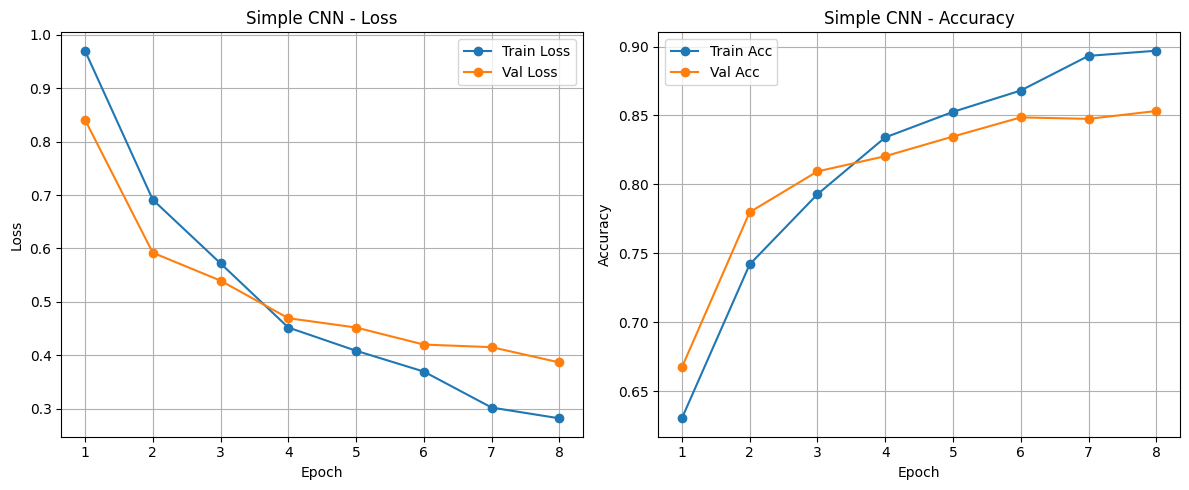

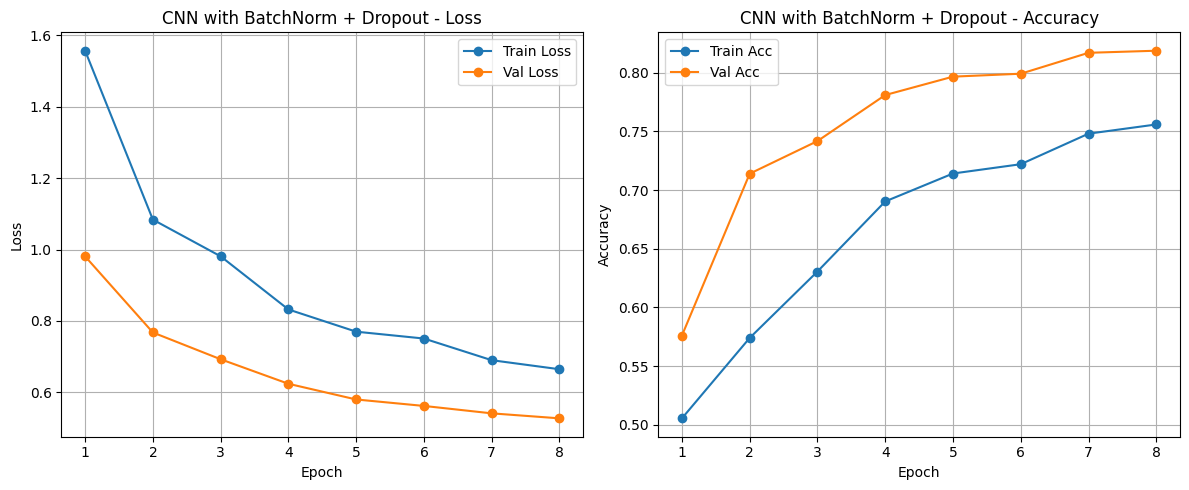

In [72]:

def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker='o', label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker='o', label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker='o', label="Train Acc")
    plt.plot(epochs, history["val_acc"], marker='o', label="Val Acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_simple, "Simple CNN")
plot_history(history_regularized, "CNN with BatchNorm + Dropout")

**Model Evaluation on Test Set**

---

Both models are evaluated on the test set using accuracy, precision, recall, and F1-score. A classification report and confusion matrix are also used for more detailed performance analysis.

In [73]:

def evaluate_model(model, loader, class_names, model_name="Model"):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    print(f"\n===== {model_name} Test Results =====")
    print("Test Accuracy:", round(acc, 4))
    print("Weighted Precision:", round(precision, 4))
    print("Weighted Recall:", round(recall, 4))
    print("Weighted F1-score:", round(f1, 4))

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    return all_labels, all_preds

**Per-Class Performance Analysis**

---

Class-wise precision, recall, F1-score, and support are analyzed in this section. The best and worst performing classes are identified based on F1-score.

In [74]:

def class_performance(all_labels, all_preds, class_names):
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0
    )

    results = []
    for i, class_name in enumerate(class_names):
        results.append({
            "class": class_name,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": support[i]
        })

    results = sorted(results, key=lambda x: x["f1"], reverse=True)

    print("Best performing class:")
    print(results[0])

    print("\nWorst performing class:")
    print(results[-1])

    print("\nAll class-wise results:")
    for r in results:
        print(r)

    return results

**Evaluate Simple CNN**

---

The simple CNN is evaluated below on the test set, followed by its per-class performance analysis.


===== Simple CNN Test Results =====
Test Accuracy: 0.8563
Weighted Precision: 0.8558
Weighted Recall: 0.8563
Weighted F1-score: 0.8559

Classification Report:

              precision    recall  f1-score   support

   buildings       0.85      0.84      0.84       437
      forest       0.95      0.97      0.96       474
     glacier       0.82      0.80      0.81       553
    mountain       0.82      0.80      0.81       525
         sea       0.84      0.87      0.85       510
      street       0.86      0.88      0.87       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



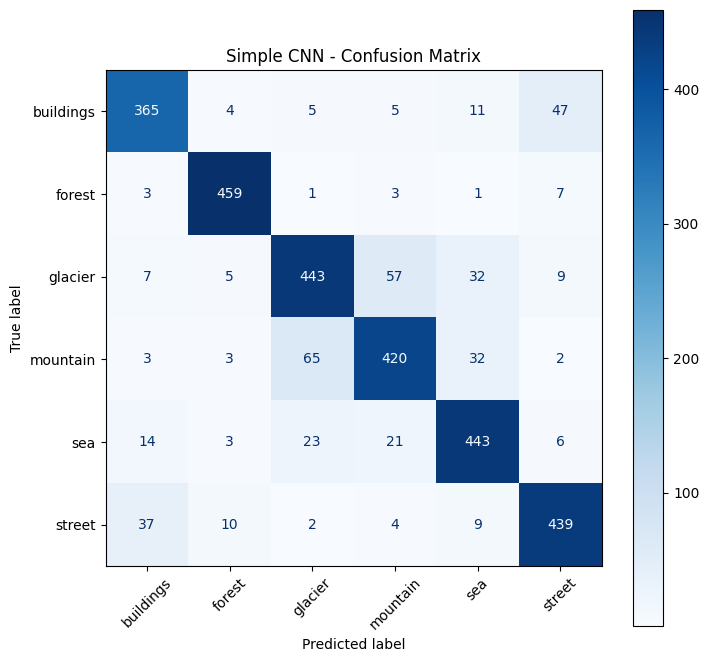

Best performing class:
{'class': 'forest', 'precision': np.float64(0.9483471074380165), 'recall': np.float64(0.9683544303797469), 'f1': np.float64(0.9582463465553236), 'support': np.int64(474)}

Worst performing class:
{'class': 'glacier', 'precision': np.float64(0.8218923933209648), 'recall': np.float64(0.8010849909584087), 'f1': np.float64(0.8113553113553114), 'support': np.int64(553)}

All class-wise results:
{'class': 'forest', 'precision': np.float64(0.9483471074380165), 'recall': np.float64(0.9683544303797469), 'f1': np.float64(0.9582463465553236), 'support': np.int64(474)}
{'class': 'street', 'precision': np.float64(0.8607843137254902), 'recall': np.float64(0.8762475049900199), 'f1': np.float64(0.8684470820969338), 'support': np.int64(501)}
{'class': 'sea', 'precision': np.float64(0.8390151515151515), 'recall': np.float64(0.8686274509803922), 'f1': np.float64(0.8535645472061657), 'support': np.int64(510)}
{'class': 'buildings', 'precision': np.float64(0.8508158508158508), 'recal

In [75]:

labels_simple, preds_simple = evaluate_model(
    model_simple,
    test_loader,
    class_names,
    model_name="Simple CNN"
)

results_simple = class_performance(labels_simple, preds_simple, class_names)

**Evaluate Regularized CNN**

---

The regularized CNN is evaluated below on the test set, followed by its per-class performance analysis.


===== Regularized CNN Test Results =====
Test Accuracy: 0.818
Weighted Precision: 0.8238
Weighted Recall: 0.818
Weighted F1-score: 0.8173

Classification Report:

              precision    recall  f1-score   support

   buildings       0.85      0.76      0.80       437
      forest       0.89      0.98      0.93       474
     glacier       0.82      0.75      0.78       553
    mountain       0.69      0.86      0.77       525
         sea       0.86      0.72      0.78       510
      street       0.84      0.84      0.84       501

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



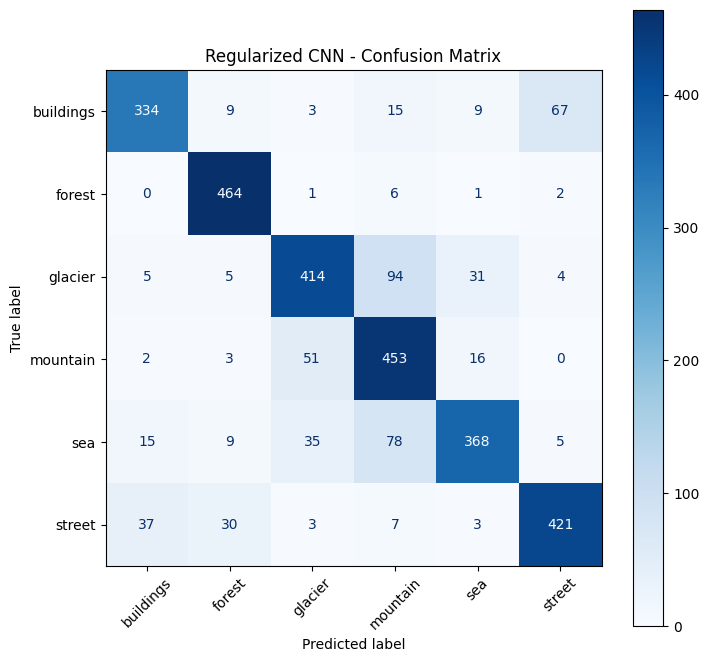

Best performing class:
{'class': 'forest', 'precision': np.float64(0.8923076923076924), 'recall': np.float64(0.9789029535864979), 'f1': np.float64(0.9336016096579477), 'support': np.int64(474)}

Worst performing class:
{'class': 'mountain', 'precision': np.float64(0.6937212863705973), 'recall': np.float64(0.8628571428571429), 'f1': np.float64(0.769100169779287), 'support': np.int64(525)}

All class-wise results:
{'class': 'forest', 'precision': np.float64(0.8923076923076924), 'recall': np.float64(0.9789029535864979), 'f1': np.float64(0.9336016096579477), 'support': np.int64(474)}
{'class': 'street', 'precision': np.float64(0.843687374749499), 'recall': np.float64(0.8403193612774451), 'f1': np.float64(0.842), 'support': np.int64(501)}
{'class': 'buildings', 'precision': np.float64(0.8498727735368957), 'recall': np.float64(0.7643020594965675), 'f1': np.float64(0.8048192771084337), 'support': np.int64(437)}
{'class': 'sea', 'precision': np.float64(0.8598130841121495), 'recall': np.float64

In [77]:

labels_reg, preds_reg = evaluate_model(
    model_regularized,
    test_loader,
    class_names,
    model_name="Regularized CNN"
)

results_reg = class_performance(labels_reg, preds_reg, class_names)

**Save Trained Model Weights**

---
The trained model weights are saved in `.pth` format so they can be reused later for inference or further training.


In [80]:

torch.save(model_simple.state_dict(), MODEL_SIMPLE_PATH)
torch.save(model_regularized.state_dict(), MODEL_REG_PATH)

print("Models saved successfully:")
print(MODEL_SIMPLE_PATH)
print(MODEL_REG_PATH)

Models saved successfully:
intel_cnn_simple_22_49008_3.pth
intel_cnn_regularized_22_49008_3.pth


**Download Saved Model Files**

---

The saved model weights are downloaded from Colab so they can be uploaded to GitHub along with the notebook file.

In [82]:

from google.colab import files

files.download(MODEL_SIMPLE_PATH)
files.download(MODEL_REG_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Comparison of Simple and Regularized Models**

---
The simple CNN and the regularized CNN are compared based on their validation and test performance. The regularized model is expected to perform better because batch normalization improves training stability and dropout helps reduce overfitting.


In [83]:

print("Simple model best class:", results_simple[0])
print("Simple model worst class:", results_simple[-1])

print("\nRegularized model best class:", results_reg[0])
print("Regularized model worst class:", results_reg[-1])

Simple model best class: {'class': 'forest', 'precision': np.float64(0.9483471074380165), 'recall': np.float64(0.9683544303797469), 'f1': np.float64(0.9582463465553236), 'support': np.int64(474)}
Simple model worst class: {'class': 'glacier', 'precision': np.float64(0.8218923933209648), 'recall': np.float64(0.8010849909584087), 'f1': np.float64(0.8113553113553114), 'support': np.int64(553)}

Regularized model best class: {'class': 'forest', 'precision': np.float64(0.8923076923076924), 'recall': np.float64(0.9789029535864979), 'f1': np.float64(0.9336016096579477), 'support': np.int64(474)}
Regularized model worst class: {'class': 'mountain', 'precision': np.float64(0.6937212863705973), 'recall': np.float64(0.8628571428571429), 'f1': np.float64(0.769100169779287), 'support': np.int64(525)}


**Conclusion and Future Work**

---

This notebook presented a complete PyTorch CNN pipeline for multi-class scene classification using the Intel Image Classification dataset. The workflow included preprocessing, data loading, custom CNN design, training, evaluation, visualization, confusion matrix analysis, class-wise analysis, and saving model weights.

Among the two models, the regularized CNN is expected to generalize better due to batch normalization and dropout. Future improvements may include training for more epochs, using deeper architectures, stronger augmentation, and transfer learning.